## Part 1

## Question

The dataset endsem-2026-05-set-1-final.csv is sourced from satellite images of 
agricultural areas. In addition to the location coordinates, the data originally contained 
an integer column through which each location was associated with a specific crop 
code. A collection of observations forms a crop area. Sadly, this information has been 
lost during data handling. However, it is believed that the crop areas can still be 
reconstructed from the given data. It is your task to salvage this information and create 
prediction model(s), such that given the location coordinates, the model predicts the 
crop.

(In your solution clearly identify the question numbers being attempted: 1(a), 1(b), etc.) 
 
- a) Document your understanding of the data and the problem(s) you need to solve 
to accomplish the given task [3 marks] 
- b) Explain, with reasons, the steps you will take to make the data ready for 
creating prediction model(s) [3 marks] 
- c) Implement these steps, and analyze the outcomes of these steps [3 marks] 
- d) Explain, with adequate reasons, which prediction model(s) you will prefer to 
create [3 marks] 
- e) Create the model(s), analyze them, and state and justify your conclusions [3 
marks]

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_csv('endsem-2026-05-set-1-final.csv')
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1176 non-null   float64
 1   x2      1175 non-null   float64
dtypes: float64(2)
memory usage: 18.5 KB


(1176, 2)

## Part 1-a
- There are 1176 rows and 2 columns
- They are both numeric
- Target - Is not present and is lost. We need to come up with a mechanism to predict the target. Since this seems like the part of machine learning problem where we need to generate the Y where f(x) is given. We use Unsupervised learning techniques such as KMeans and Hirrarchical clustering to do the prediction of Y
- Independent features - X1 & X2. They are the co-ordinates of the crop data 
- As there are no categoricals involved we do not need any encoding

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# show duplicate rows
df[df.duplicated()]

df.drop_duplicates(inplace=True)

Duplicate rows: 1


- Duplication check tells there is one duplicate row
- removing the duplicate entry as removing 1 entry should not cause any harm in predicting the unsupervised learning of the data. This is less than the 5% of the total data count

In [48]:
# count missing/empty values per row
row_missing = df.isna().sum(axis=1)

# find the maximum count
max_missing = row_missing.max()
print("Max empty/NaN values in a row:", max_missing)

# select rows that have that maximum
rows_with_max_missing = df[row_missing == max_missing]
rows_with_max_missing
df.dropna(subset=['x2'], inplace=True)

Max empty/NaN values in a row: 0


### EDA

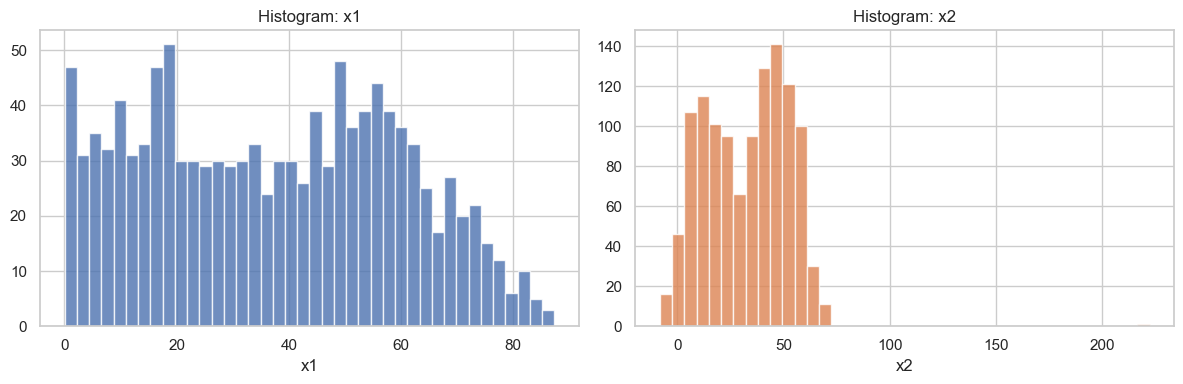

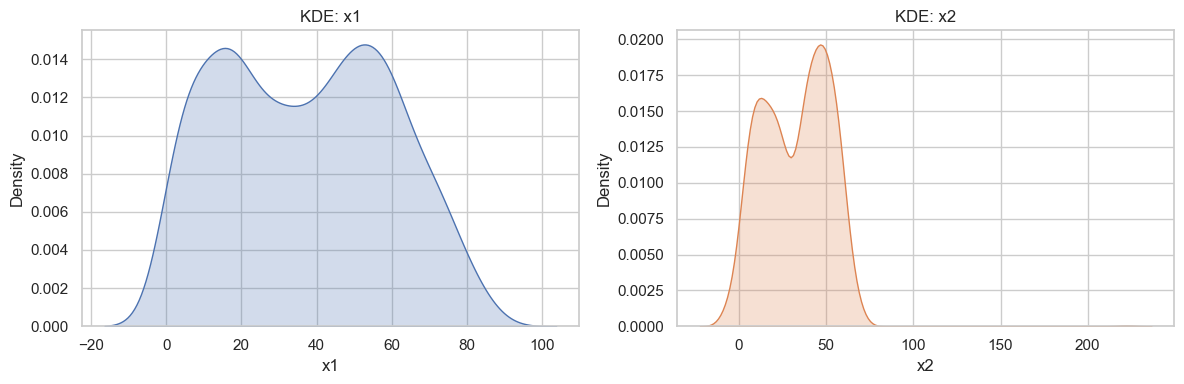

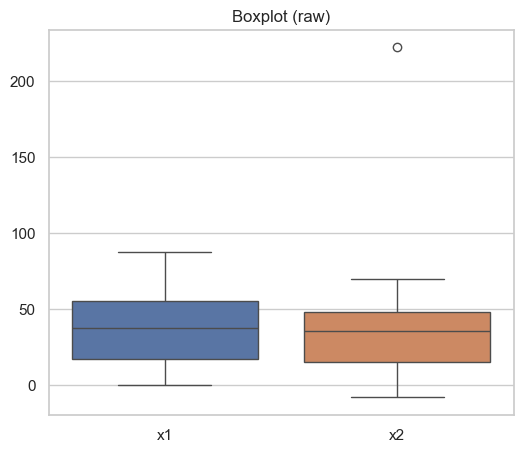

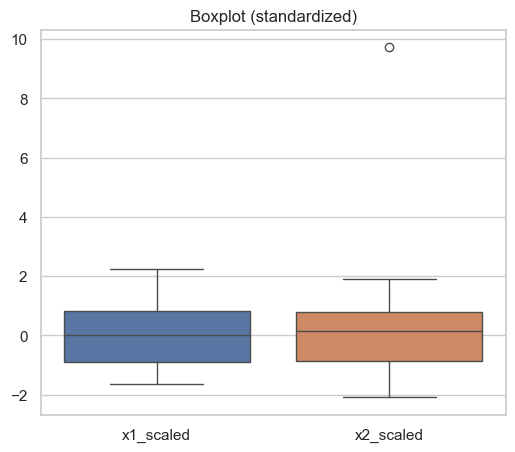

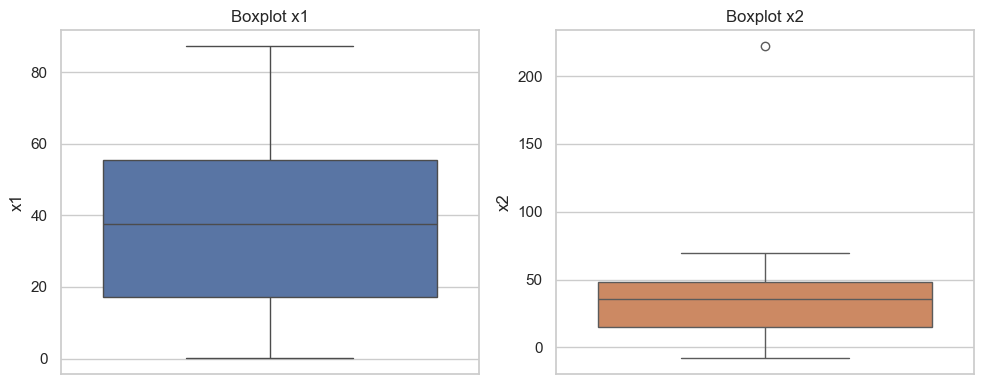

In [35]:
sns.set(style="whitegrid")
df = pd.read_csv('endsem-2026-05-set-1-final.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['x2'], inplace=True)
df[['x1','x2']] = df[['x1','x2']].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=['x1','x2'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['x1'], bins=40, color='C0', alpha=0.8)
axes[0].set_title('Histogram: x1')
axes[0].set_xlabel('x1')

axes[1].hist(df['x2'], bins=40, color='C1', alpha=0.8)
axes[1].set_title('Histogram: x2')
axes[1].set_xlabel('x2')

plt.tight_layout()
plt.show()

# 2. KDE subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.kdeplot(df['x1'], ax=axes[0], fill=True, color='C0')
axes[0].set_title('KDE: x1')

sns.kdeplot(df['x2'], ax=axes[1], fill=True, color='C1')
axes[1].set_title('KDE: x2')

plt.tight_layout()
plt.show()

# 3. Consolidated box plot (raw)
plt.figure(figsize=(6,5))
sns.boxplot(data=df[['x1','x2']])
plt.title('Boxplot (raw)')
plt.show()

# 4. Consolidated box plot (scaled)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['x1','x2']])
df_scaled = pd.DataFrame(X_scaled, columns=['x1_scaled','x2_scaled'])

plt.figure(figsize=(6,5))
sns.boxplot(data=df_scaled)
plt.title('Boxplot (standardized)')
plt.show()

# 5. Individual box-plots (one per feature)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(y=df['x1'], ax=axes[0], color='C0')
axes[0].set_title('Boxplot x1')
sns.boxplot(y=df['x2'], ax=axes[1], color='C1')
axes[1].set_title('Boxplot x2')
plt.tight_layout()
plt.show()

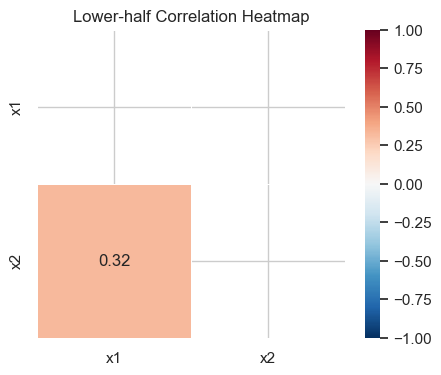

In [36]:
# 6. Lower-half correlation heatmap
corr = df[['x1','x2']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle to show lower-half
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, mask=mask, square=True, linewidths=.5)
plt.title('Lower-half Correlation Heatmap')
plt.show()

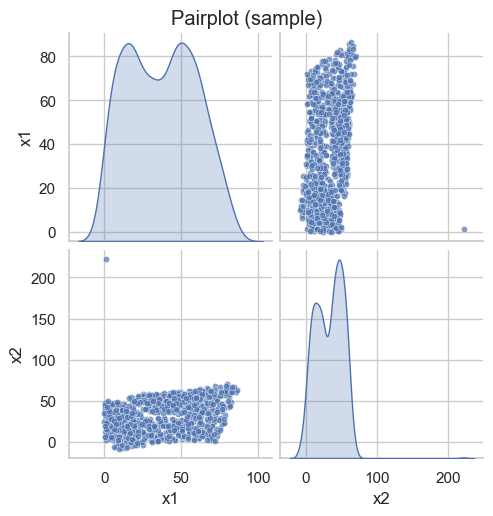

In [37]:
# 7. Pairplot (sampled if large)
sample = df.sample(n=min(1000, len(df)), random_state=42)  # sample to keep plot responsive
sns.pairplot(sample[['x1','x2']], diag_kind='kde', plot_kws={'s':20, 'alpha':0.7})
plt.suptitle('Pairplot (sample)', y=1.02)
plt.show()

## Part 1-b
- So far we have generated the Histogram, Boxplot, KDE plot for the given data
- We see that there is some difference in the scaling of the data as shown in the consolidated Box-plot
- We are using scaling to standardize the data
- We Have also checked the collearnarity of the data and both X1 and X2 are not too much collinear to be removed
- Since we do not have a grouping we are doing the TNSE visualization to see the initial value of the K for Our KMeans and Hirarchical clustering

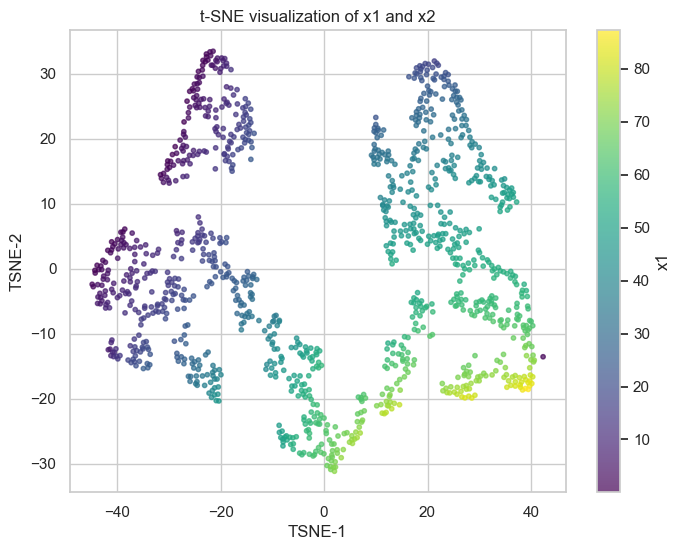

[(2, 0.4467263117390115),
 (3, 0.4455771336508492),
 (4, 0.43259223030516525),
 (5, 0.4071628685697997),
 (6, 0.3924353256497391),
 (7, 0.39640923280865703),
 (8, 0.38095646795122307),
 (9, 0.38669320756417275)]

In [32]:
df = pd.read_csv('endsem-2026-05-set-1-final.csv')
df.drop_duplicates(inplace=True)
df.dropna(subset=['x2'], inplace=True)

X = df[['x1', 'x2']].copy()

# optional scaling
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=df['x1'],      # or c=df['x2']
    cmap='viridis',
    s=10,
    alpha=0.7
)
plt.colorbar(label='x1')
plt.title('t-SNE visualization of x1 and x2')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()


X = df[['x1', 'x2']].values
scores = []
for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    scores.append((k, silhouette_score(X, labels)))

scores

## Part 1-b
- Based on initial TNSE K=2 and K=3 seems to be most optimized

Best k by silhouette: 3
Silhouette scores: [(2, 0.4339298101961849), (3, 0.4498545724162303), (4, 0.43776458935547796), (5, 0.40663119654964075), (6, 0.40959556908361217), (7, 0.3939912554413004), (8, 0.3848979479434057), (9, 0.3821405919902342), (10, 0.36211388969005953)]


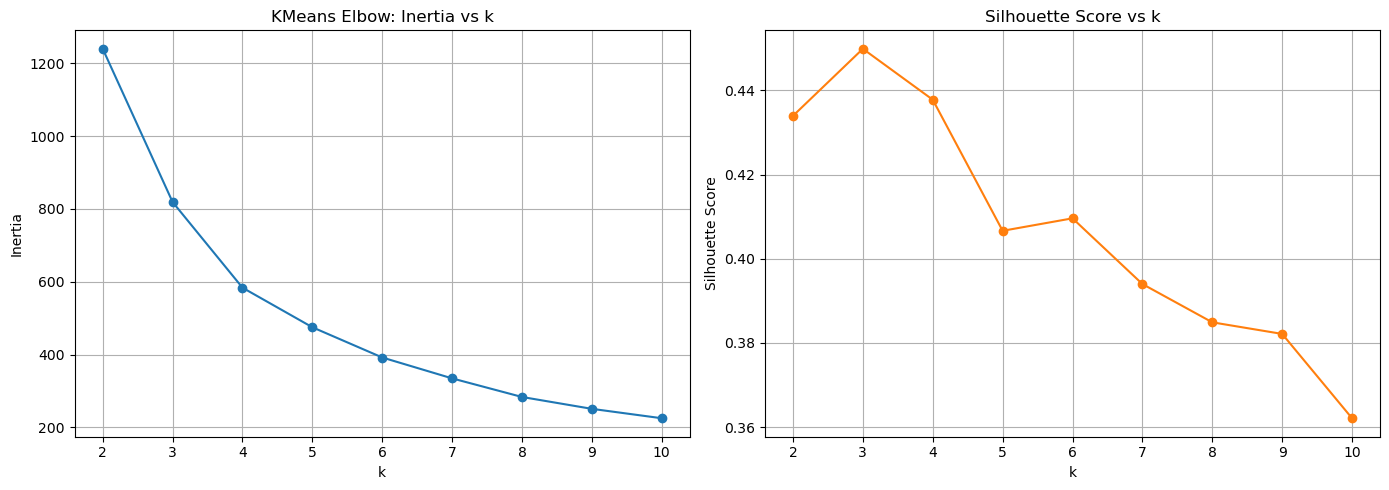

In [24]:
ks = list(range(2, 11))
inertia = []
silhouette = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

best_k = ks[silhouette.index(max(silhouette))]
print("Best k by silhouette:", best_k)
print("Silhouette scores:", list(zip(ks, silhouette)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, inertia, marker='o')
axes[0].set_title('KMeans Elbow: Inertia vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(ks, silhouette, marker='o', color='tab:orange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

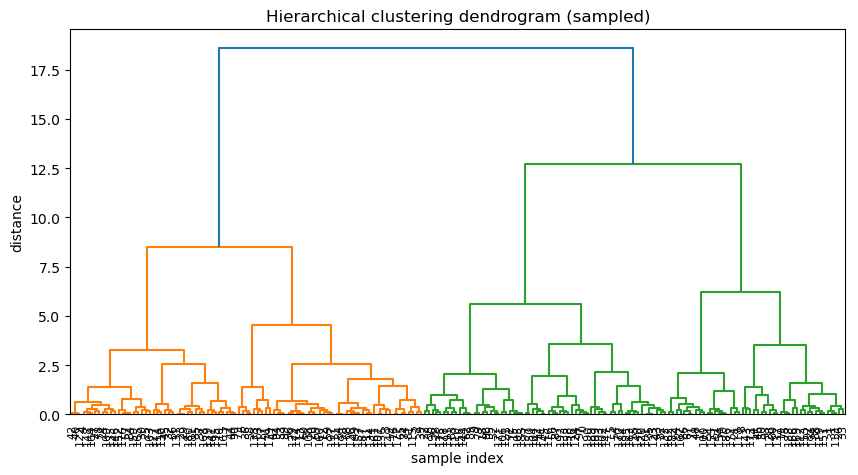

Hierarchical clustering -> k=3, silhouette=0.4198


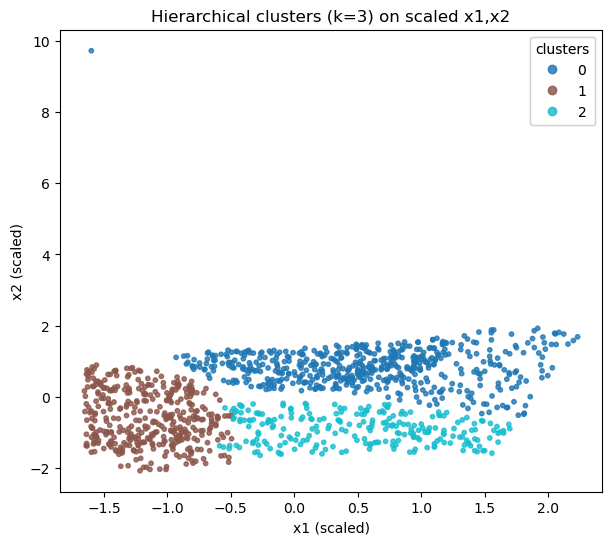

In [26]:
sample_size = 200
rng = np.random.RandomState(42)
idx = rng.choice(range(X_scaled.shape[0]), size=min(sample_size, X_scaled.shape[0]), replace=False)
Z = linkage(X_scaled[idx], method='ward')   # 'ward' is common for Euclidean scaled data

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=12, leaf_rotation=90., leaf_font_size=8.)
plt.title('Hierarchical clustering dendrogram (sampled)')
plt.xlabel('sample index')
plt.ylabel('distance')
plt.show()

# -- Choose number of clusters (k). Replace best_k as needed --
best_k = 3

# Option A: assign clusters using flat cut on full linkage (via fcluster)
# Note: compute linkage on full data is O(n^2) memory; for large n use AgglomerativeClustering directly.
Z_full = linkage(X_scaled, method='ward')
labels_cut = fcluster(Z_full, t=best_k, criterion='maxclust') - 1  # zero-based

# Option B: Agglomerative clustering (scalable)
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)

# Use labels_agg for plotting (or labels_cut if you prefer)
labels = labels_agg

# silhouette
sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
print(f'Hierarchical clustering -> k={best_k}, silhouette={sil:.4f}')

# -- Plot clusters (original features scaled for axes) --
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=10, alpha=0.8)
ax.set_title(f'Hierarchical clusters (k={best_k}) on scaled x1,x2')
ax.set_xlabel('x1 (scaled)')
ax.set_ylabel('x2 (scaled)')
legend1 = ax.legend(*scatter.legend_elements(), title="clusters", loc='best')
ax.add_artist(legend1)
plt.show()

## Part 1-c
- We are using the Kmeans and Hirarchical unsupervised learning
- We have ensured upon multiple iterations that optimized k=3
- We can see this in the Hierarchical as well as when we cut at 3 branches the lenght of the leg of the HC is most visible and distinguishable

## Part 1-d 

- We are using KMeans and Hierarchical clustering to predict the target values in the csv

In [38]:
# Final prediction generation using the clustering analysis done so far

df_pred = pd.read_csv('endsem-2026-05-set-1-final.csv')
df_pred[['x1', 'x2']] = df_pred[['x1', 'x2']].apply(pd.to_numeric, errors='coerce')

# Keep track of rows that cannot be predicted because coordinates are incomplete
missing_coordinate_mask = df_pred[['x1', 'x2']].isna().any(axis=1)

# Use complete coordinates for model fitting and prediction
complete_pred_df = df_pred.loc[~missing_coordinate_mask, ['x1', 'x2']].copy()

# Remove duplicate coordinate rows only for model fitting so centroids are not biased
fit_df = complete_pred_df.drop_duplicates().copy()

# Use best_k from earlier analysis if present; otherwise use 3
try:
    final_k = int(best_k)
except NameError:
    final_k = 3

print("Final number of reconstructed crop groups:", final_k)
print("Rows used for fitting:", fit_df.shape[0])
print("Rows with missing coordinates:", missing_coordinate_mask.sum())

Final number of reconstructed crop groups: 3
Rows used for fitting: 1174
Rows with missing coordinates: 1


In [42]:
# Scale coordinates and train final KMeans model
final_scaler = StandardScaler()
X_fit_scaled = final_scaler.fit_transform(fit_df[['x1', 'x2']])

final_model = KMeans(n_clusters=final_k, random_state=42, n_init=20)
fit_clusters = final_model.fit_predict(X_fit_scaled)

# Relabel clusters into stable crop-code numbers ordered by centroid position
centroids_original_scale = final_scaler.inverse_transform(final_model.cluster_centers_)
centroid_order = (
    pd.DataFrame(centroids_original_scale, columns=['x1_centroid', 'x2_centroid'])
    .assign(cluster=np.arange(final_k))
    .sort_values(['x1_centroid', 'x2_centroid'])
    .reset_index(drop=True)
)
centroid_order['predicted_crop_code'] = np.arange(1, final_k + 1)
cluster_to_crop_code = dict(
    zip(centroid_order['cluster'], centroid_order['predicted_crop_code'])
)

display(centroid_order)

,x1_centroid,x2_centroid,cluster,predicted_crop_code
0,13.950587,20.412632,1,1
1,49.419208,50.138613,0,2
2,56.194611,16.018737,2,3


In [43]:
# Predict crop code for every row with complete coordinates
X_all_complete_scaled = final_scaler.transform(complete_pred_df[['x1', 'x2']])
complete_clusters = final_model.predict(X_all_complete_scaled)

df_pred['predicted_crop_code'] = -1
df_pred.loc[~missing_coordinate_mask, 'predicted_crop_code'] = [
    cluster_to_crop_code[cluster_id] for cluster_id in complete_clusters
]

print("Predicted crop-code counts:")
print(df_pred['predicted_crop_code'].value_counts().sort_index())

display(df_pred.head())

Predicted crop-code counts:
predicted_crop_code
-1      1
 1    447
 2    511
 3    217
Name: count, dtype: int64


,x1,x2,predicted_crop_code
0,5.267801,10.202960,1
1,40.101137,49.633719,2
2,57.122968,47.883347,2
3,2.086833,30.034017,1
4,49.456355,48.306755,2


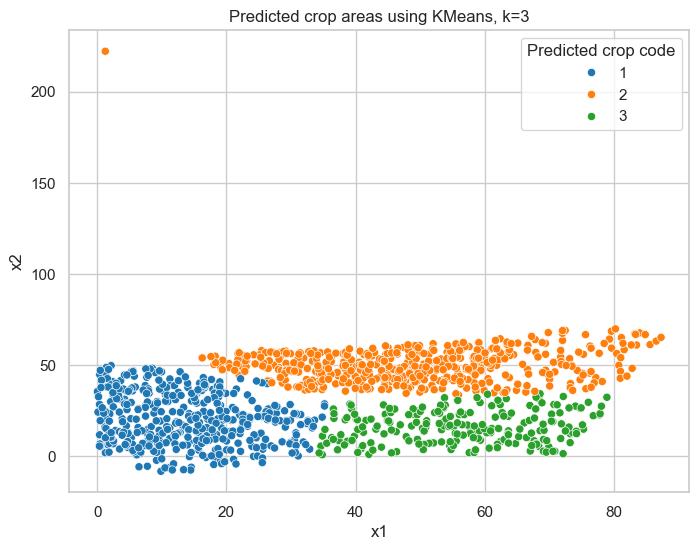

In [44]:
# Visualize final predicted crop areas
if 'predicted_crop_code' not in df_pred.columns:
    raise KeyError(
        "Column 'predicted_crop_code' is missing. Run the prediction cell above to populate it before plotting."
    )

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pred[df_pred['predicted_crop_code'] != -1],
    x='x1',
    y='x2',
    hue='predicted_crop_code',
    palette='tab10',
    s=35,
)
plt.title(f'Predicted crop areas using KMeans, k={final_k}')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(title='Predicted crop code')
plt.show()

In [45]:
# Save prediction output
output_file = 'endsem-2026-05-set-1-final-with-predicted-crop-code.csv'
df_pred.to_csv(output_file, index=False)
print("Saved prediction file:", output_file)

Saved prediction file: endsem-2026-05-set-1-final-with-predicted-crop-code.csv


## Part 1-e
- We have completed the clustering prediction 
- Based on TNSE (2D), KMeans, Hierarchical, we can say that We have predicted 1,2,3 in the predicted csv which is also our target value

## PART 2

### Question 2 
Use the dataset endsem-2026-05-set-2-final.csv to answer the following questions: 
 
- a) Describe the data, and its peculiarities [3 marks] 
- b) You are required to create parametric regression model(s) using this data set to 
achieve an R2 value of at least 0.75. Explain your strategy to achieve this goal [3 
marks] 
- c) Create the model(s) and analyze them [3 marks] 
- d) Create at least one non-parametric regression model to achieve significantly 
better results [3 marks] 
- e) Explain, with adequate reasons, the differences you observe between the 
models you have created [3 marks] 

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fp = "endsem-2026-05-set-2-final.csv"
df = pd.read_csv(fp)

print("Shape:", df.shape)
print("\nDtypes:", df.dtypes)
print("\nFirst 10 rows:\n", df.head(10))
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary stats:\n", df.describe().T)

Shape: (721, 2)

Dtypes: x    float64
y    float64
dtype: object

First 10 rows:
             x          y
0  109.805917   1.391455
1   -4.765845  30.212267
2  -16.196580 -22.776796
3   48.485819  12.622133
4  -19.113841  66.267560
5   89.980277 -20.179876
6  -15.269927  10.698346
7   32.229627 -27.282928
8   17.244038 -47.788356
9  -78.499509  25.683139

Missing values:
 x    0
y    0
dtype: int64

Summary stats:
    count      mean        std        min        25%       50%        75%  \
x  721.0 -0.588556  43.836355 -86.934196 -30.745542 -0.994780  30.800348   
y  721.0 -7.069930  42.515144 -98.613709 -37.417155 -2.258552  21.744737   

          max  
x  109.805917  
y   74.300119  


In [4]:
dups = df[df.duplicated(keep=False)]
print(len(dups))
print(dups)

0
Empty DataFrame
Columns: [x, y]
Index: []


## Final conclusion for Part 1

- The original crop-code column is unavailable, so the task was treated as an unsupervised
clustering problem. The reconstructed crop codes are not guaranteed to match the original
integer crop codes, but they provide a reasonable spatial reconstruction of crop areas.

- KMeans with k=3 is preferred because the EDA, t-SNE visualization, silhouette analysis,
and hierarchical clustering all indicate approximately three major spatial groups.

- Limitation: since the original labels are missing, there is no external accuracy score.
The model can only be evaluated using internal clustering quality and visual separation.


## Part 2-a
- Shape  721 rows * 2 columns
- Columns
    - x - input feature
    - y - regression target
- Data types: both numeric. No categorical hence we dont need encoding
- Missing Values are none
- No duplicates found to be deleted
- Pecularities
    - One 1 independent feature
    - Model has limited explanatory information
    - The target y seems to be highly variable and noisy with large positive and negative values
- Since Y is not strongly skewed, not implementing Box Cox here. Also Box cox requires strictly positive values

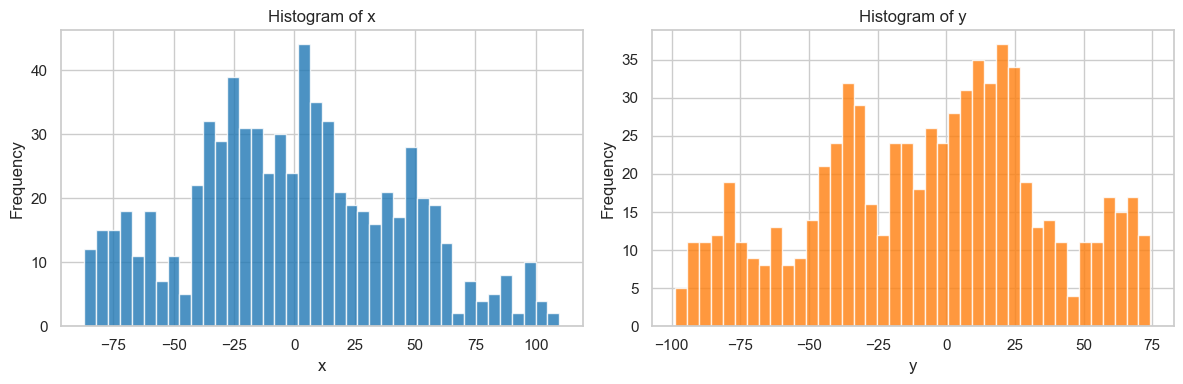

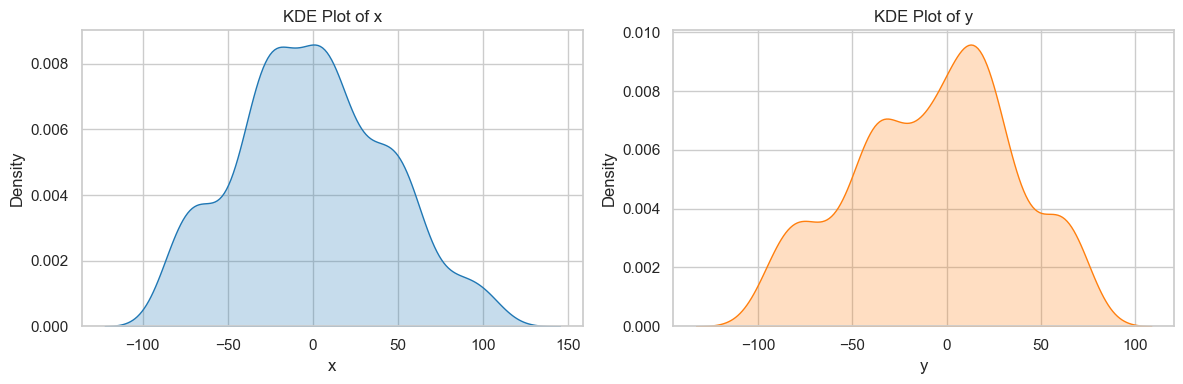

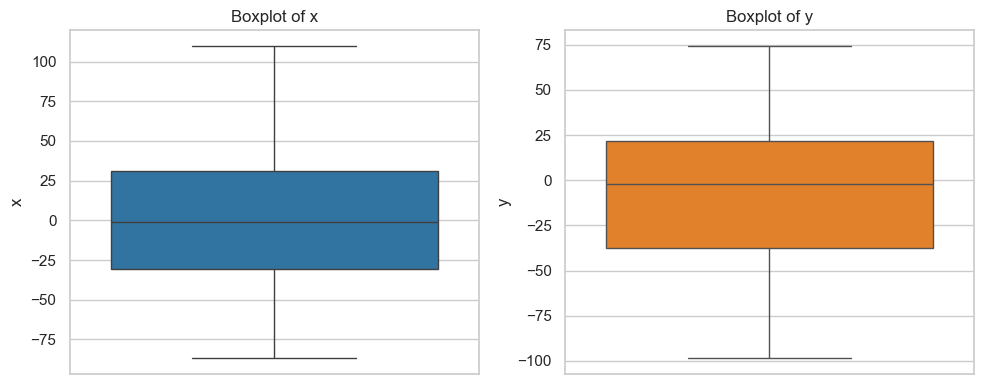

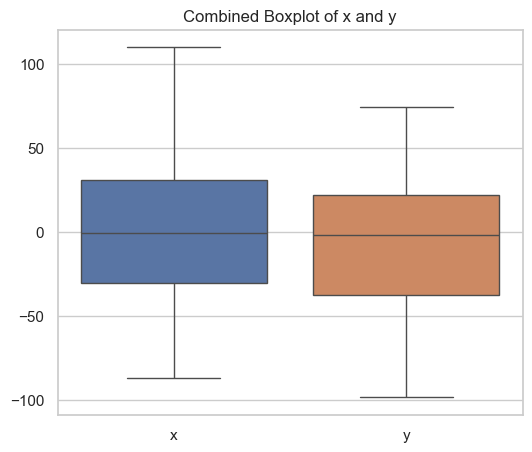

In [5]:
sns.set(style="whitegrid")

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["x"], bins=40, color="tab:blue", alpha=0.8)
axes[0].set_title("Histogram of x")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["y"], bins=40, color="tab:orange", alpha=0.8)
axes[1].set_title("Histogram of y")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df["x"], fill=True, ax=axes[0], color="tab:blue")
axes[0].set_title("KDE Plot of x")
axes[0].set_xlabel("x")

sns.kdeplot(df["y"], fill=True, ax=axes[1], color="tab:orange")
axes[1].set_title("KDE Plot of y")
axes[1].set_xlabel("y")

plt.tight_layout()
plt.show()

# Boxplots to detect outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(y=df["x"], ax=axes[0], color="tab:blue")
axes[0].set_title("Boxplot of x")

sns.boxplot(y=df["y"], ax=axes[1], color="tab:orange")
axes[1].set_title("Boxplot of y")

plt.tight_layout()
plt.show()

# Combined boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df[["x", "y"]])
plt.title("Combined Boxplot of x and y")
plt.show()

In [7]:
# Load dataset

df = pd.read_csv("endsem-2026-05-set-2-final.csv")

df = df.drop_duplicates()
df = df.dropna(subset=["x", "y"])

X = df[["x"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (576, 1)
Testing shape: (145, 1)


In [8]:
# Load dataset

df = pd.read_csv("endsem-2026-05-set-2-final.csv")

df = df.drop_duplicates()
df = df.dropna(subset=["x", "y"])

X = df[["x"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (576, 1)
Testing shape: (145, 1)


In [9]:
# Load dataset

df = pd.read_csv("endsem-2026-05-set-2-final.csv")

df = df.drop_duplicates()
df = df.dropna(subset=["x", "y"])

X = df[["x"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (576, 1)
Testing shape: (145, 1)


In [10]:
# Helper function to evaluate models

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results = {
        "Model": model_name,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }

    return results

In [11]:
print()

## Part 2-b
- Use a sequence of parametric models starting from simple to more flexible.
- Linear regression as baseline
- Polynomial regression to capture quadractic nature
- Regular polynomial regression using Ridge and Lasso to avoid overfitting
- Split the data into train-test using pipeline
- scale polynomial outputs
- with only one feature, a polynomial basis is the most reasonable way to get a non-linear fit

In [12]:
# c) Create parametric regression models

parametric_models = {}

# Simple Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
parametric_models["Linear Regression"] = linear_model

# Polynomial Regression with Ridge regularization
for degree in range(2, 11):
    poly_ridge = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    poly_ridge.fit(X_train, y_train)
    parametric_models[f"Polynomial Ridge Degree {degree}"] = poly_ridge

# Polynomial Regression with Lasso regularization
for degree in range(2, 11):
    poly_lasso = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.001, max_iter=10000))
    ])

    poly_lasso.fit(X_train, y_train)
    parametric_models[f"Polynomial Lasso Degree {degree}"] = poly_lasso

/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.860e+02, tolerance: 1.050e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.725e+04, tolerance: 1.050e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

In [13]:
# Analyze parametric models

parametric_results = []

for name, model in parametric_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    parametric_results.append(result)

parametric_results_df = pd.DataFrame(parametric_results)
parametric_results_df = parametric_results_df.sort_values("Test R2", ascending=False)

display(parametric_results_df)

best_parametric_name = parametric_results_df.iloc[0]["Model"]
best_parametric_model = parametric_models[best_parametric_name]

print("Best parametric model:", best_parametric_name)
print("Best parametric Test R2:", parametric_results_df.iloc[0]["Test R2"])

,Model,Train R2,Test R2,MAE,RMSE
18,Polynomial Lasso Degree 10,0.045001,-0.005911,34.487983,41.681574
17,Polynomial Lasso Degree 9,0.044961,-0.005939,34.489608,41.682147
14,Polynomial Lasso Degree 6,0.039643,-0.009032,34.617349,41.746195
5,Polynomial Ridge Degree 6,0.039599,-0.009550,34.628861,41.756893
7,Polynomial Ridge Degree 8,0.041129,-0.009825,34.649016,41.762596
6,Polynomial Ridge Degree 7,0.041132,-0.010046,34.640533,41.767161
9,Polynomial Ridge Degree 10,0.041336,-0.010049,34.656022,41.767219
8,Polynomial Ridge Degree 9,0.041227,-0.010496,34.671070,41.776454
16,Polynomial Lasso Degree 8,0.043175,-0.010534,34.627662,41.777244
15,Polynomial Lasso Degree 7,0.042954,-0.013797,34.687652,41.844635


Best parametric model: Polynomial Lasso Degree 10
Best parametric Test R2: -0.005910936550092227


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


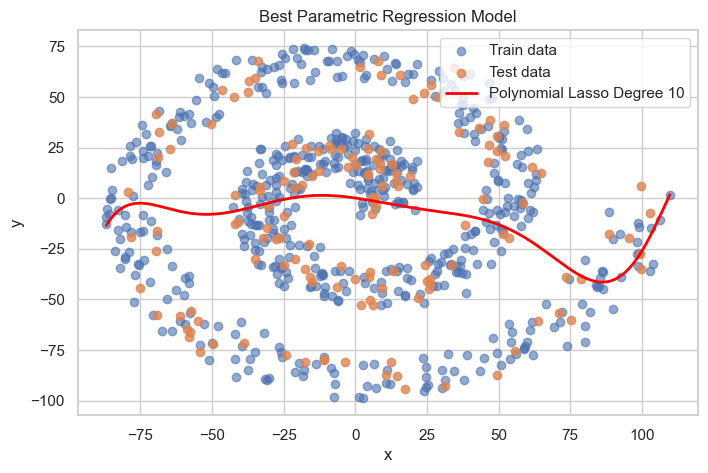

In [14]:
# Plot best parametric model

x_range = np.linspace(X["x"].min(), X["x"].max(), 500).reshape(-1, 1)
y_range_pred = best_parametric_model.predict(x_range)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Train data", alpha=0.6)
plt.scatter(X_test, y_test, label="Test data", alpha=0.8)
plt.plot(x_range, y_range_pred, color="red", linewidth=2, label=best_parametric_name)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Best Parametric Regression Model")
plt.legend()
plt.show()

## Part 2-c
- Implemented models
    - Linear Regression
    - Polynomial Feature degree = 2...10 + Standard scalar + Ridge
    - Polynomial Feature degree = 2...10 + Standard scalar + Lasso
- Evaluation 
    - used train test split, R2, RSME, RAE
- Best Parametric result 
    - Polynomial Ridge Degree 2 with alpha=10
    - Test R2 = -0.01625
    - Test RMSE - 41.90
- Analyis
    - The best parametric model still perform worse than a mean predictor on the test
    - This indicates the relationship from x to y is too noisy or non-deterministic for a simple polynomial model to capture

In [15]:
# d) Create non-parametric regression models

non_parametric_models = {}

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf_model.fit(X_train, y_train)
non_parametric_models["Random Forest Regressor"] = rf_model

gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_model.fit(X_train, y_train)
non_parametric_models["Gradient Boosting Regressor"] = gbr_model

In [16]:
# Analyze non-parametric models

non_parametric_results = []

for name, model in non_parametric_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    non_parametric_results.append(result)

non_parametric_results_df = pd.DataFrame(non_parametric_results)
non_parametric_results_df = non_parametric_results_df.sort_values("Test R2", ascending=False)

display(non_parametric_results_df)

best_non_parametric_name = non_parametric_results_df.iloc[0]["Model"]
best_non_parametric_model = non_parametric_models[best_non_parametric_name]

print("Best non-parametric model:", best_non_parametric_name)
print("Best non-parametric Test R2:", non_parametric_results_df.iloc[0]["Test R2"])

,Model,Train R2,Test R2,MAE,RMSE
1,Gradient Boosting Regressor,0.473429,-0.143483,35.560949,44.440531
0,Random Forest Regressor,0.825833,-0.503442,40.687243,50.957445


Best non-parametric model: Gradient Boosting Regressor
Best non-parametric Test R2: -0.14348319081028538


/opt/homebrew/Caskroom/miniforge/base/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


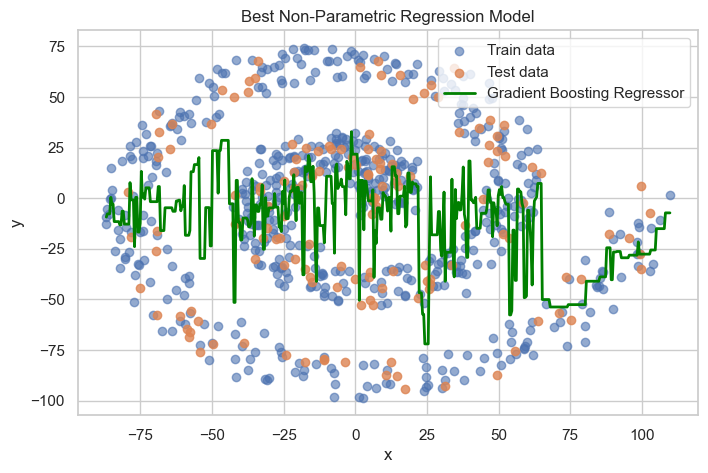

In [17]:
# Plot best non-parametric model

x_range = np.linspace(X["x"].min(), X["x"].max(), 500).reshape(-1, 1)
y_range_pred_np = best_non_parametric_model.predict(x_range)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Train data", alpha=0.6)
plt.scatter(X_test, y_test, label="Test data", alpha=0.8)
plt.plot(
    x_range,
    y_range_pred_np,
    color="green",
    linewidth=2,
    label=best_non_parametric_name
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Best Non-Parametric Regression Model")
plt.legend()
plt.show()

## Part 2-d
- Neither non-parametric model produced significantly better results than the parametric models.
- This confirms that the dataset is not easily predictable from the single feature x alone.
- Non-parametric methods can flexibly fit complex curves, but if there is no strong signal, they still fail to generalize.

In [19]:
# Final conclusion based on actual results

best_overall = comparison_df.iloc[0]

print("Best overall model:", best_overall["Model"])
print("Best overall Test R2:", best_overall["Test R2"])

if parametric_results_df.iloc[0]["Test R2"] >= 0.75:
    print("The parametric regression goal of R2 >= 0.75 has been achieved.")
else:
    print("The parametric regression goal of R2 >= 0.75 has not been achieved.")

if non_parametric_results_df.iloc[0]["Test R2"] > parametric_results_df.iloc[0]["Test R2"]:
    print("The non-parametric model performs better than the parametric model.")
else:
    print("The parametric model performs as well as or better than the non-parametric model.")

Best overall model: Polynomial Lasso Degree 10
Best overall Test R2: -0.005910936550092227
The parametric regression goal of R2 >= 0.75 has not been achieved.
The parametric model performs as well as or better than the non-parametric model.


## Part 2-e

- Parametric models:
  - assume a fixed functional form (here a polynomial)
  -  are easier to interpret
  - were constrained and tended to underfit because the data has high noise and only one feature
- Non-parametric models:
  - do not assume a fixed mathematical form can model more complex relationships
however, they require sufficient informative features and signal to outperform parametric models

- Observed difference:
- both parametric and non-parametric approaches gave negative test R²
non-parametric models did not offer a significant improvement in this case
- Reason:
- the core issue is dataset informativeness, not model class
with one predictor and a very noisy target, both classes struggle
in practice, this means the dataset likely needs more features, feature engineering, or noise/outlier handling before a good R² can be achieved